In [87]:
import sys
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor
processor = LogProcessor('../../logs/etf_mm@15_04_2025_2133.log')
processor.read_log()

In [88]:
logs = processor.sandbox_logs
logs

,sandboxLog,lambdaLog
timestamp,,
0,,"(58707.0, 4)"
100,,"(58711.55960146101, 4)"
200,,"(58719.273712936585, 4)"
300,,"(58719.175659771645, 4)"
400,,"(58717.12834642546, 4)"
...,...,...
99500,,"(58905.284228306424, 4)"
99600,,"(58902.784228306424, 4)"
99700,,"(58908.684228306425, 4)"


In [89]:
fair_prices = logs.apply(lambda row: eval(row['lambdaLog'])[0],axis=1)
std = logs.apply(lambda row: eval(row['lambdaLog'])[1],axis=1)

In [90]:
price_data = processor.activities_log
picnic_data = price_data[price_data['product']=="PICNIC_BASKET1"]
mid = picnic_data.mid_price
mid.index = picnic_data.timestamp
mid

timestamp
0        58707.0
100      58709.5
200      58715.5
300      58716.5
400      58715.5
          ...   
99500    58903.5
99600    58900.5
99700    58904.5
99800    58906.5
99900    58896.5
Name: mid_price, Length: 1000, dtype: float64

<Axes: xlabel='mid_price', ylabel='Density'>

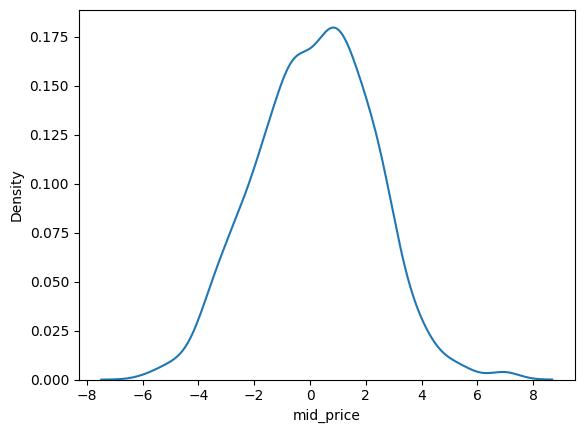

In [91]:
sns.kdeplot(mid.diff().rolling(5).mean())

In [92]:
mid.diff().std()

4.863600829618271

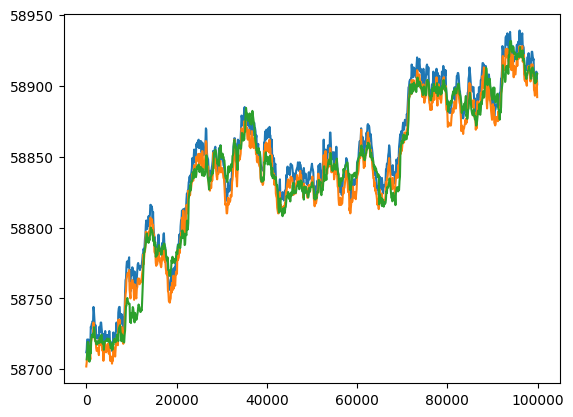

In [93]:
# plt.plot(fair_prices)
highest_pnl = 0
best_signal = None
best_upper = None 
best_lower = None
best_fact = None
fig,ax = plt.subplots(nrows=1)

asks = picnic_data.ask_price_1
asks.index = picnic_data.timestamp
bids = picnic_data.bid_price_1
bids.index = picnic_data.timestamp
std_vals = std

upper = asks + std_vals
lower = bids - std_vals
ax.plot(asks)
ax.plot(bids)
ax.plot(fair_prices.shift(1))
# ax.scatter(mid,fair_prices.shift(1))